# Parte II - Busca classica no labirinto conhecido

Analise dos algoritmos obrigatorios: BFS, DFS, UCS, Gulosa e A*.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = Path.cwd()
if BASE.name == "notebooks":
    BASE = BASE.parent
DATA = BASE / "datasets"

arquivos = {
    "BFS": "resultado_bfs.csv",
    "DFS": "resultado_dfs.csv",
    "UCS": "resultado_ucs.csv",
    "Gulosa": "resultado_guloso.csv",
    "A*": "resultado_a_star.csv",
}

mazes = pd.read_csv(DATA / "mazes.csv").rename(columns={"id": "maze_id"})
frames = []
for algoritmo, arquivo in arquivos.items():
    caminho = DATA / arquivo
    if caminho.exists():
        df = pd.read_csv(caminho)
        df["algoritmo"] = algoritmo
        frames.append(df)

classicas = pd.concat(frames, ignore_index=True)
classicas = classicas.merge(mazes, on="maze_id", how="left")
classicas["area"] = classicas["width"] * classicas["length"]
classicas.head()

,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,algoritmo,width,length,collectibles,cicles,start,end,area
0,625bac15-9499-4a79-9e7a-48dae6218341,True,1660,1661,159241,159246,0.485831,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3...",BFS,627.0,495.0,3.0,0.048911,"(1, 1)","(625, 493)",310365.0
1,7add276b-52a5-45fe-981a-21865cf46e49,True,2146,2147,111179,111182,0.401186,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 2...",BFS,611.0,361.0,12.0,0.022134,"(1, 1)","(609, 359)",220571.0
2,a2700719-8e47-4c0d-a23a-e1ce2a12ad21,True,646,647,39905,39927,0.070731,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (5, 2...",BFS,169.0,427.0,1.0,0.207742,"(1, 1)","(167, 425)",72163.0
3,54c7d169-1041-415d-80d2-f492a89d64d8,True,892,893,49992,49993,0.094125,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5...",BFS,623.0,143.0,21.0,0.221363,"(1, 1)","(621, 141)",89089.0
4,579f484b-5a9d-4248-867e-3517c5df2507,True,1422,1423,132527,132528,0.371791,"[(1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (4, 3...",BFS,861.0,287.0,27.0,0.128376,"(1, 1)","(859, 285)",247107.0


In [2]:
# Cobertura de resultados por algoritmo.
total_mazes = mazes["maze_id"].nunique()
cobertura = (
    classicas.groupby("algoritmo")["maze_id"]
    .nunique()
    .rename("resultados")
    .reset_index()
)
cobertura["esperados"] = total_mazes
cobertura["faltantes"] = cobertura["esperados"] - cobertura["resultados"]
cobertura.sort_values("algoritmo")

,algoritmo,resultados,esperados,faltantes
0,A*,50,50,0
1,BFS,50,50,0
2,DFS,43,50,7
3,Gulosa,50,50,0
4,UCS,50,50,0


In [3]:
# Tabela experimental minima solicitada no trabalho.
tabela = (
    classicas.groupby("algoritmo")
    .agg(
        sucesso=("sucesso", "mean"),
        custo_medio=("custo", "mean"),
        passos_medios=("passos", "mean"),
        expandidos_medios=("expandidos", "mean"),
        tempo_medio=("tempo_segundos", "mean"),
        fronteira_media=("fronteira", "mean"),
    )
    .reset_index()
)
tabela["sucesso"] = (tabela["sucesso"] * 100).round(1)
tabela.round(4)

,algoritmo,sucesso,custo_medio,passos_medios,expandidos_medios,tempo_medio,fronteira_media
0,A*,100.0,1196.9600,1197.9600,81500.5000,0.3883,1363.5000
1,BFS,100.0,1196.9600,1197.9600,122980.3000,0.6017,122985.3200
2,DFS,100.0,4190.5909,4191.5909,23839.8864,1.6053,24786.3864
3,Gulosa,100.0,1594.3200,1595.3200,2117.5600,0.0125,2465.4000
4,UCS,100.0,1196.9600,1197.9600,135647.0400,0.6285,135652.5800


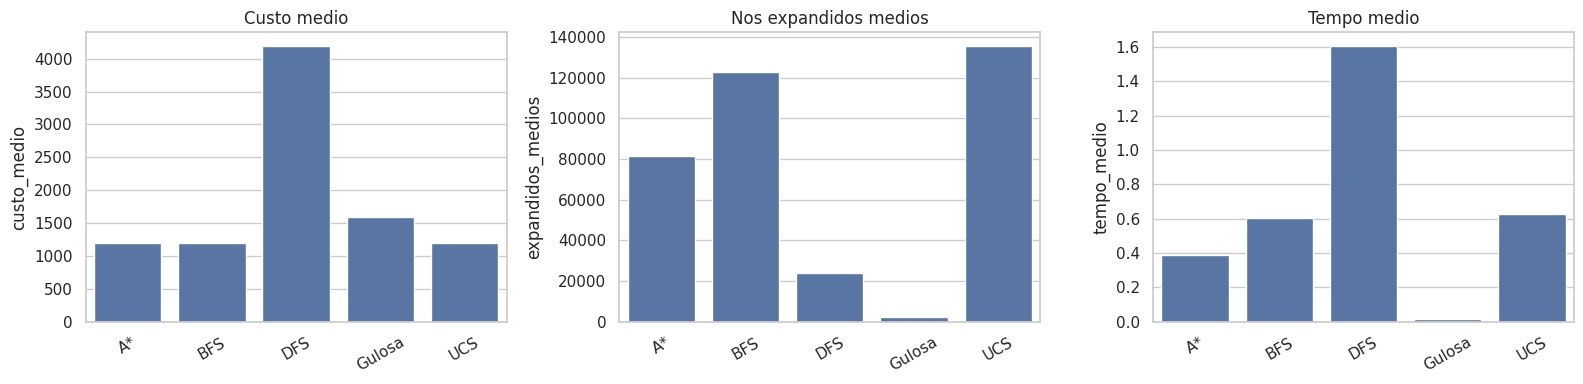

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=tabela, x="algoritmo", y="custo_medio", ax=axes[0])
axes[0].set_title("Custo medio")
axes[0].set_xlabel("")

sns.barplot(data=tabela, x="algoritmo", y="expandidos_medios", ax=axes[1])
axes[1].set_title("Nos expandidos medios")
axes[1].set_xlabel("")

sns.barplot(data=tabela, x="algoritmo", y="tempo_medio", ax=axes[2])
axes[2].set_title("Tempo medio")
axes[2].set_xlabel("")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [5]:
# Comparacao direta de otimalidade em custo contra BFS/UCS/A*.
custos = classicas.pivot_table(index="maze_id", columns="algoritmo", values="custo", aggfunc="first")
custos["BFS_igual_UCS"] = custos.get("BFS") == custos.get("UCS")
custos["A*_igual_UCS"] = custos.get("A*") == custos.get("UCS")
custos["Gulosa_igual_UCS"] = custos.get("Gulosa") == custos.get("UCS")
custos[["BFS_igual_UCS", "A*_igual_UCS", "Gulosa_igual_UCS"]].mean().mul(100).round(1)

algoritmo
BFS_igual_UCS       100.0
A*_igual_UCS        100.0
Gulosa_igual_UCS      0.0
dtype: float64

## Questoes de analise solicitadas

1. BFS encontrou o menor caminho? Em labirintos com custo unitario por movimento, BFS deve encontrar menor numero de passos. Compare `BFS_igual_UCS` acima.
2. DFS encontrou solucao rapidamente? Compare tempo, expandidos e custo. DFS nao garante solucao otima.
3. UCS diferiu de BFS quando os custos variaram? Nesta implementacao o custo de movimento e unitario; por isso UCS tende a coincidir com BFS.
4. A busca gulosa foi eficiente? Foi otima? Compare expandidos/tempo contra `Gulosa_igual_UCS`.
5. A* equilibrou qualidade e eficiencia? Compare `A*_igual_UCS`, expandidos e tempo.
6. A heuristica e admissivel? A distancia Manhattan e admissivel para movimentos ortogonais com custo unitario, pois nunca superestima a distancia minima sem obstaculos.

Atencao: a coluna `fronteira` nos CSVs antigos pode representar insercoes acumuladas, nao necessariamente o tamanho maximo da fronteira. Se o codigo for corrigido, gere novamente os resultados antes de fechar o relatorio.